In [ ]:
#  Python Script for plotting ring parameters compared to 400*400 resolution parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv('/home/amandeep-kaur/aspire-black-hole-project/Data_files/Blurring_ring_stats.csv')
resolution= data["n0"]
ring_size = data["ring_size"]
ring_width = data["ring_width"]
position_angle = data["pa"]

In [ ]:
# Standard parameters for M87 observed ring
# M87_ring_size=21
# ring_size_sigma = 1.5
# M87_PA=175
# PA_sigma =1.5 

In [3]:
# Mean of the parameters based on 400*400

M87_ring_size   = data.loc[data["n0"] == 400, "ring_size"].mean()
ring_size_sigma = data.loc[data["n0"] == 400, "ring_size"].std()

M87_ring_width  = data.loc[data["n0"] == 400, "ring_width"].mean()
ring_width_sigma = data.loc[data["n0"] == 400, "ring_width"].std()

M87_position_angle  = data.loc[data["n0"] == 400, "pa"].mean()
position_angle_sigma = data.loc[data["n0"] == 400, "pa"].std()
print(M87_position_angle)


147.9264696


# Plot between Ring_size and Resolution

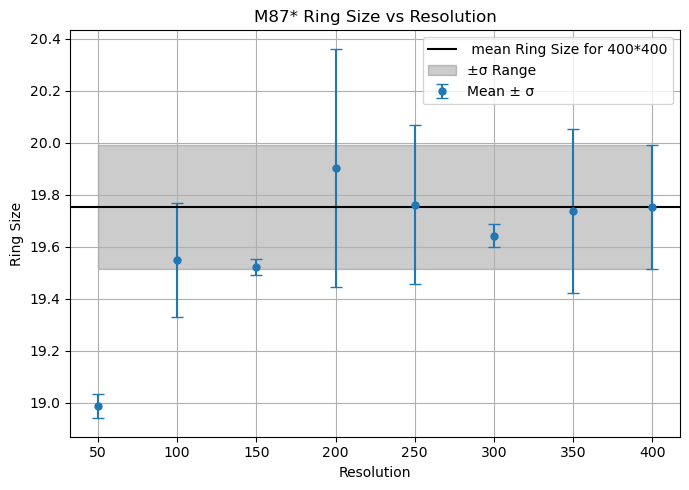

In [4]:
grouped_RS= (
    data
    .groupby("n0")["ring_size"]
    .agg(mean="mean", sigma="std")
    .reset_index()
)

x = grouped_RS["n0"].values
y = grouped_RS["mean"].values
yerr = grouped_RS["sigma"].values



lower_bound = M87_ring_size - ring_size_sigma
upper_bound = M87_ring_size + ring_size_sigma

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Mean ± σ per Resolution
ax.errorbar(
    x, y,
    yerr,
    fmt='o',
    capsize=4,
    markersize=5,
    label='Mean ± σ '
)

# Global mean line
ax.axhline(
    M87_ring_size,
    color='black',
    linestyle='-',
    linewidth=1.5,
    label=' mean Ring Size for 400*400'
)

# Global ±σ band
ax.fill_between(
    x,
    lower_bound,
    upper_bound,
    color='black',
    alpha=0.2,
    label='±σ Range'
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel('Resolution')
ax.set_ylabel('Ring Size')
ax.set_title('M87* Ring Size vs Resolution')

ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()

# Plot between Ring Width & Resolution

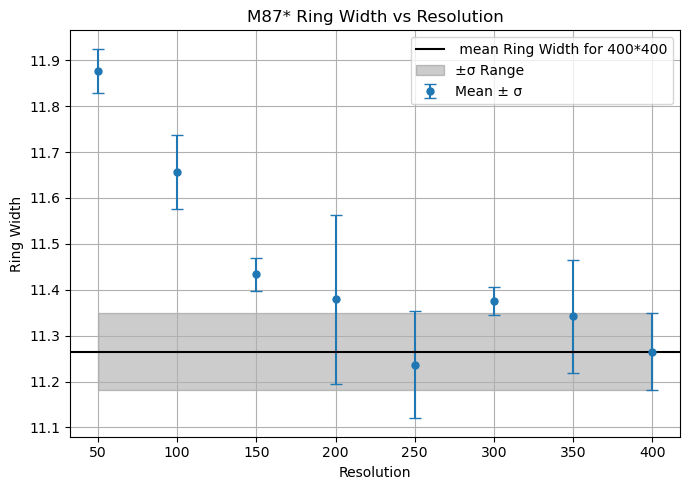

In [5]:
grouped_RW= (
    data
    .groupby("n0")["ring_width"]
    .agg(mean="mean", sigma="std")
    .reset_index()
)

x = grouped_RW["n0"].values
y = grouped_RW["mean"].values
yerr = grouped_RW["sigma"].values



lower_bound = M87_ring_width - ring_width_sigma
upper_bound = M87_ring_width + ring_width_sigma

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Mean ± σ per Resolution
ax.errorbar(
    x, y,
    yerr,
    fmt='o',
    capsize=4,
    markersize=5,
    label='Mean ± σ '
)

# Global mean line
ax.axhline(
    M87_ring_width,
    color='black',
    linestyle='-',
    linewidth=1.5,
    label=' mean Ring Width for 400*400'
)

# Global ±σ band
ax.fill_between(
    x,
    lower_bound,
    upper_bound,
    color='black',
    alpha=0.2,
    label='±σ Range'
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel('Resolution')
ax.set_ylabel('Ring Width')
ax.set_title('M87* Ring Width vs Resolution')

ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()

# Plot between Position angle & Resolution

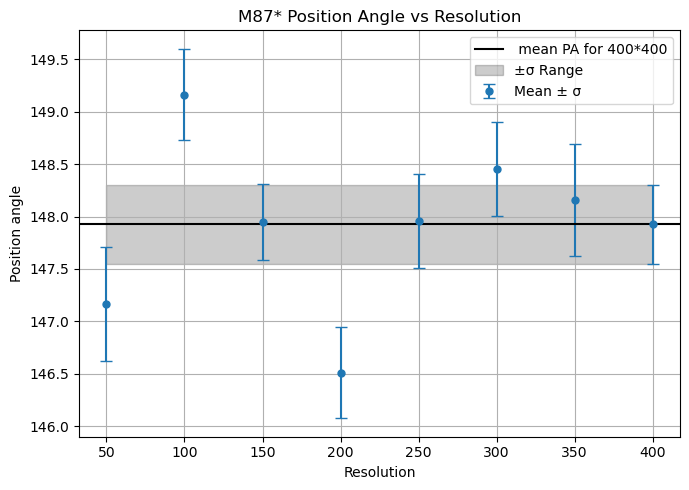

In [6]:
grouped_PA = (
    data
    .groupby("n0")["pa"]
    .agg(mean="mean", sigma="std")
    .reset_index()
)

x = grouped_PA["n0"].values
z = grouped_PA["mean"].values
zerr = grouped_PA["sigma"].values



lower_bound = M87_position_angle - position_angle_sigma
upper_bound = M87_position_angle + position_angle_sigma

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Mean ± σ per Resolution
ax.errorbar(
    x, z,
    yerr=zerr,
    fmt='o',
    capsize=4,
    markersize=5,
    label='Mean ± σ '
)

# Global mean line
ax.axhline(
    M87_position_angle,
    color='black',
    linestyle='-',
    linewidth=1.5,
    label=' mean PA for 400*400'
)

# Global ±σ band
ax.fill_between(
    x,
    lower_bound,
    upper_bound,
    color='black',
    alpha=0.2,
    label='±σ Range'
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel('Resolution')
ax.set_ylabel('Position angle')
ax.set_title('M87* Position Angle vs Resolution')

ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()